# Geological Cross-Section for Groundwater Visualization

This notebook demonstrates how to use the `geological_cross_section` module to create professional geological cross-sections showing groundwater systems, aquifers, and wells.

## Setup

First, let's import the necessary modules:

In [1]:
import sys
sys.path.insert(0, '../src')

from geological_cross_section import GeologicalCrossSection, GeologicalLayer, Well
from geological_cross_section.cross_section import create_example_cross_section
from IPython.display import HTML, SVG, display

## Quick Start: Example Cross-Section

The easiest way to get started is to use the built-in example cross-section:

In [2]:
# Create an example cross-section
cross_section = create_example_cross_section()

print(f"Title: {cross_section.title}")
print(f"Number of layers: {len(cross_section.layers)}")
print(f"Number of wells: {len(cross_section.wells)}")
print(f"Horizontal extent: {min(cross_section.x_positions)}m to {max(cross_section.x_positions)}m")

Title: Groundwater Cross-Section: Alluvial Valley Aquifer System
Number of layers: 5
Number of wells: 3
Horizontal extent: 0m to 1000m


## Display the SVG Cross-Section

Generate and display the SVG visualization:

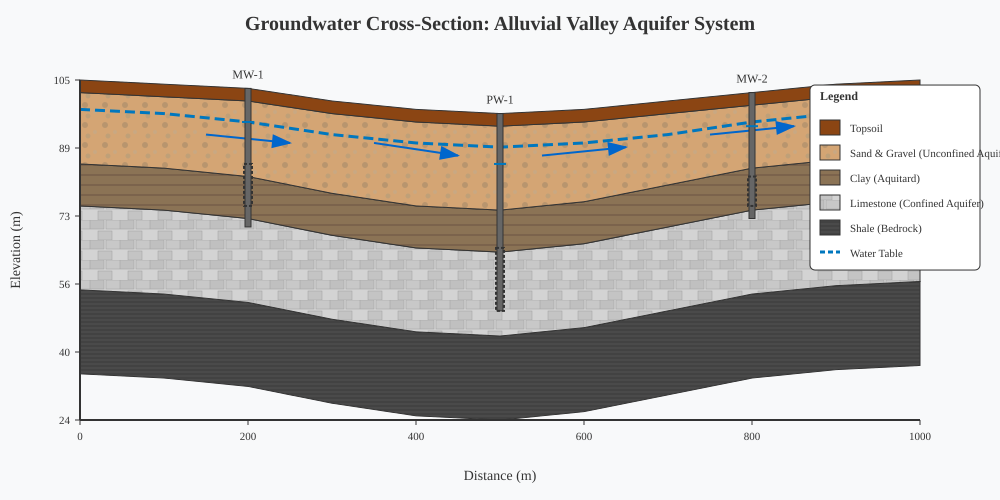

In [3]:
# Generate SVG and display it
svg_content = cross_section.generate_svg(width=1000, height=500)
display(SVG(svg_content))

## Inspect the Geological Layers

Let's look at the details of each geological layer:

In [4]:
for i, layer in enumerate(cross_section.layers, 1):
    aquifer_status = "✓ AQUIFER" if layer.is_aquifer else "✗ Aquitard/Confining"
    k_value = f"K = {layer.hydraulic_conductivity} m/d" if layer.hydraulic_conductivity else "N/A"
    
    print(f"Layer {i}: {layer.name}")
    print(f"  Pattern: {layer.pattern}")
    print(f"  Type: {aquifer_status}")
    print(f"  Hydraulic Conductivity: {k_value}")
    print(f"  Description: {layer.description}")
    print()

Layer 1: Topsoil
  Pattern: solid
  Type: ✗ Aquitard/Confining
  Hydraulic Conductivity: N/A
  Description: Organic-rich surface soil

Layer 2: Sand & Gravel (Unconfined Aquifer)
  Pattern: gravel
  Type: ✓ AQUIFER
  Hydraulic Conductivity: K = 50.0 m/d
  Description: High-permeability alluvial deposits

Layer 3: Clay (Aquitard)
  Pattern: clay
  Type: ✗ Aquitard/Confining
  Hydraulic Conductivity: K = 0.001 m/d
  Description: Low-permeability confining layer

Layer 4: Limestone (Confined Aquifer)
  Pattern: limestone
  Type: ✓ AQUIFER
  Hydraulic Conductivity: K = 15.0 m/d
  Description: Fractured carbonate aquifer

Layer 5: Shale (Bedrock)
  Pattern: shale
  Type: ✗ Aquitard/Confining
  Hydraulic Conductivity: N/A
  Description: Impermeable basement rock



## Inspect the Wells

View details about the wells in the cross-section:

In [5]:
for well in cross_section.wells:
    print(f"Well: {well.name} ({well.well_type})")
    print(f"  Position: {well.x_position}m along section")
    print(f"  Depth: {well.top_elevation - well.bottom_elevation}m")
    print(f"  Screen interval: {well.screen_top}m to {well.screen_bottom}m elevation")
    if well.water_level:
        print(f"  Water level: {well.water_level}m elevation")
    if well.pumping_rate:
        print(f"  Pumping rate: {well.pumping_rate} m³/d")
    print()

Well: MW-1 (monitoring)
  Position: 200m along section
  Depth: 33m
  Screen interval: 85m to 75m elevation
  Water level: 95m elevation

Well: PW-1 (production)
  Position: 500m along section
  Depth: 47m
  Screen interval: 65m to 50m elevation
  Water level: 85m elevation
  Pumping rate: 500.0 m³/d

Well: MW-2 (monitoring)
  Position: 800m along section
  Depth: 30m
  Screen interval: 82m to 75m elevation
  Water level: 94m elevation



## Creating a Custom Cross-Section

Now let's create a custom cross-section from scratch:

In [6]:
# Define x positions (distance along the section in meters)
x_positions = [0, 50, 100, 150, 200, 250, 300]

# Create a new cross-section
custom_section = GeologicalCrossSection(
    title="Simple Two-Aquifer System",
    x_positions=x_positions,
    vertical_exaggeration=5.0
)

# Add topsoil layer
custom_section.add_layer(GeologicalLayer(
    name="Topsoil",
    top_elevations=[50, 48, 46, 45, 46, 48, 50],
    bottom_elevations=[47, 45, 43, 42, 43, 45, 47],
    color="#8B4513",
    pattern="solid",
    description="Surface soil layer"
))

# Add unconfined aquifer (sand)
custom_section.add_layer(GeologicalLayer(
    name="Sand Aquifer (Unconfined)",
    top_elevations=[47, 45, 43, 42, 43, 45, 47],
    bottom_elevations=[35, 33, 30, 28, 30, 33, 35],
    color="#f4d03f",
    pattern="sand",
    is_aquifer=True,
    hydraulic_conductivity=30.0,
    description="Unconfined sandy aquifer"
))

# Add clay aquitard
custom_section.add_layer(GeologicalLayer(
    name="Clay Aquitard",
    top_elevations=[35, 33, 30, 28, 30, 33, 35],
    bottom_elevations=[25, 23, 20, 18, 20, 23, 25],
    color="#8b7355",
    pattern="clay",
    is_aquifer=False,
    hydraulic_conductivity=0.001,
    description="Confining clay layer"
))

# Add confined aquifer (gravel)
custom_section.add_layer(GeologicalLayer(
    name="Gravel Aquifer (Confined)",
    top_elevations=[25, 23, 20, 18, 20, 23, 25],
    bottom_elevations=[10, 8, 5, 3, 5, 8, 10],
    color="#d4a574",
    pattern="gravel",
    is_aquifer=True,
    hydraulic_conductivity=100.0,
    description="High-yield confined aquifer"
))

# Add bedrock
custom_section.add_layer(GeologicalLayer(
    name="Bedrock",
    top_elevations=[10, 8, 5, 3, 5, 8, 10],
    bottom_elevations=[0, 0, 0, 0, 0, 0, 0],
    color="#4a4a4a",
    pattern="shale",
    description="Impermeable basement"
))

print("Custom cross-section created!")

Custom cross-section created!


In [7]:
# Add water table
custom_section.set_water_table([45, 43, 40, 38, 40, 43, 45])

# Add a monitoring well in the unconfined aquifer
custom_section.add_well(Well(
    name="MW-1",
    x_position=75,
    top_elevation=45,
    bottom_elevation=32,
    screen_top=40,
    screen_bottom=32,
    water_level=41,
    well_type="monitoring"
))

# Add a production well in the confined aquifer
custom_section.add_well(Well(
    name="PW-1",
    x_position=200,
    top_elevation=46,
    bottom_elevation=8,
    screen_top=18,
    screen_bottom=8,
    water_level=35,
    well_type="production",
    pumping_rate=200.0
))

# Add groundwater flow arrows
custom_section.add_flow_arrow(50, 40, 100, 38)
custom_section.add_flow_arrow(150, 38, 200, 39)

print("Wells, water table, and flow arrows added!")

Wells, water table, and flow arrows added!


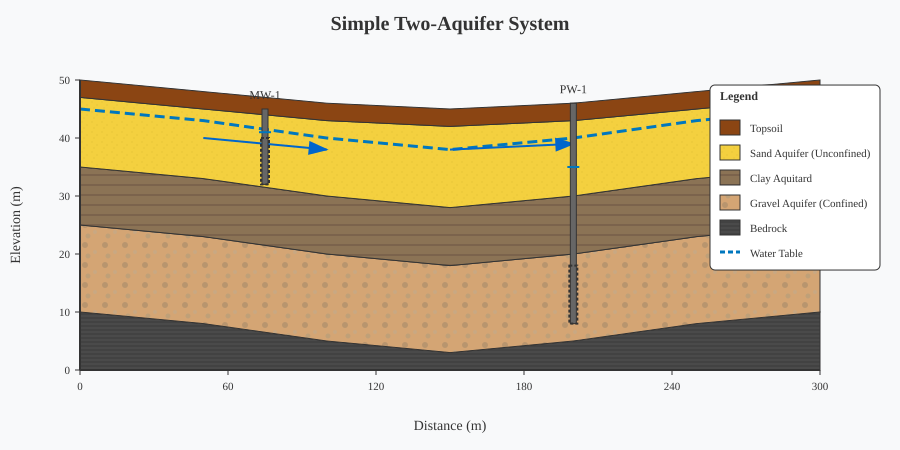

In [8]:
# Display the custom cross-section
custom_svg = custom_section.generate_svg(width=900, height=450)
display(SVG(custom_svg))

## Export to JSON

The cross-section data can be exported to JSON for storage or sharing:

In [9]:
import json

# Export to JSON
json_data = custom_section.to_json()

# Pretty print the JSON
parsed = json.loads(json_data)
print(json.dumps(parsed, indent=2)[:1500] + "\n... (truncated)")

{
  "title": "Simple Two-Aquifer System",
  "x_positions": [
    0,
    50,
    100,
    150,
    200,
    250,
    300
  ],
  "vertical_exaggeration": 5.0,
  "layers": [
    {
      "name": "Topsoil",
      "top_elevations": [
        50,
        48,
        46,
        45,
        46,
        48,
        50
      ],
      "bottom_elevations": [
        47,
        45,
        43,
        42,
        43,
        45,
        47
      ],
      "color": "#8B4513",
      "pattern": "solid",
      "is_aquifer": false,
      "hydraulic_conductivity": null,
      "description": "Surface soil layer"
    },
    {
      "name": "Sand Aquifer (Unconfined)",
      "top_elevations": [
        47,
        45,
        43,
        42,
        43,
        45,
        47
      ],
      "bottom_elevations": [
        35,
        33,
        30,
        28,
        30,
        33,
        35
      ],
      "color": "#f4d03f",
      "pattern": "sand",
      "is_aquifer": true,
      "hydraulic_conductivit

## Available Geological Patterns

The module supports several geological patterns for different rock/sediment types:

In [10]:
patterns_info = {
    "solid": "Plain solid color fill",
    "gravel": "Pebble/cobble texture for alluvial deposits, gravels",
    "sand": "Fine dotted pattern for sandy sediments",
    "clay": "Horizontal lines for clay, silt, mud",
    "limestone": "Block/brick pattern for carbonate rocks",
    "shale": "Thin parallel lines for shale, mudstone"
}

print("Available Patterns:")
print("=" * 50)
for pattern, description in patterns_info.items():
    print(f"  {pattern:12} - {description}")

Available Patterns:
  solid        - Plain solid color fill
  gravel       - Pebble/cobble texture for alluvial deposits, gravels
  sand         - Fine dotted pattern for sandy sediments
  clay         - Horizontal lines for clay, silt, mud
  limestone    - Block/brick pattern for carbonate rocks
  shale        - Thin parallel lines for shale, mudstone


## Save Cross-Section to File

Save the visualization as an HTML file for sharing:

In [11]:
# Generate full HTML with interactive features
html_content = custom_section.generate_html(width=1000, height=500)

# Save to file
output_path = "custom_cross_section_output.html"
with open(output_path, "w") as f:
    f.write(html_content)

print(f"Saved interactive HTML to: {output_path}")
print(f"File size: {len(html_content):,} bytes")

Saved interactive HTML to: custom_cross_section_output.html
File size: 13,953 bytes


## Summary

This module provides:

- **GeologicalCrossSection**: Main class for creating cross-sections
- **GeologicalLayer**: Define geological units with patterns and properties
- **Well**: Add monitoring and production wells
- **SVG/HTML generation**: Professional visualizations
- **JSON export**: Data interchange format

Use this for:
- Groundwater studies
- Environmental assessments
- Hydrogeological reports
- Educational materials